# DeepLens 端到端光学设计与折衍混合优化教程

本教程将演示如何使用 DeepLens 框架进行完整的光学系统设计，包括：

1. **端到端透镜设计**：创建4片透镜系统，目标参数为 F/2.8、FOV 84°、焦距 4.0mm
2. **光学性能评估**：分析PSF、MTF、畸变等光学指标
3. **折衍混合设计**：在折射透镜基础上添加DOE（衍射光学元件）进行联合优化
4. **混合透镜评估**：评估折衍混合透镜的光学性能

## 技术参考

- **端到端设计**: Xinge Yang, Qiang Fu, Wolfgang Heidrich, "Curriculum learning for ab initio deep learned refractive optics," Nature Communications 2024.
- **折衍混合设计**: Xinge Yang et al., "End-to-End Hybrid Refractive-Diffractive Lens Design with Differentiable Ray-Wave Model," SIGGRAPH Asia 2024.

## 1. 导入必要的库

首先导入 DeepLens 框架的核心模块和其他必要的依赖库。

In [1]:
import os
import math
import random
import string
from datetime import datetime

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from torchvision.utils import save_image

# DeepLens core modules
from deeplens import GeoLens
from deeplens.hybridlens import HybridLens
from deeplens.geolens_pkg.utils import create_lens
from deeplens.optics.loss import PSFLoss
from deeplens.basics import DEPTH, EPSILON, WAVE_RGB

# Utility functions
from deeplens.utils import set_seed, set_logger

# Set random seed for reproducibility
set_seed(42)

# Set matplotlib style for white background and black text
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['text.color'] = 'black'
plt.rcParams['axes.labelcolor'] = 'black'
plt.rcParams['xtick.color'] = 'black'
plt.rcParams['ytick.color'] = 'black'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.titlecolor'] = 'black'

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Create result directory
result_dir = f"./results/tutorial_{datetime.now().strftime('%m%d-%H%M%S')}"
os.makedirs(result_dir, exist_ok=True)
print(f"Results will be saved to: {result_dir}")

Using device: cuda
Results will be saved to: ./results/tutorial_0207-184619


## 2. 加载或创建透镜系统

本节提供两种方式来获取初始透镜：

### 选项 A：从已有透镜文件加载
从 `datasets/lenses/` 目录中加载预设计的透镜文件（JSON或ZMX格式）

### 选项 B：从头创建新透镜
使用 `create_lens()` 函数创建自定义参数的透镜设计起点

**可用的透镜文件：**
- `datasets/lenses/cellphone/`: 手机镜头 (cellphone68deg, cellphone80deg等)
- `datasets/lenses/camera/`: 相机镜头 (ef50mm, rf35mm等)
- `datasets/lenses/cooke.json`: Cooke三合镜
- `datasets/lenses/zemax_double_gaussian.zmx`: Zemax双高斯设计

In [2]:
# ============================================
# 透镜选择配置
# ============================================

# 设置为 True 使用已有透镜文件，False 则创建新透镜
USE_EXISTING_LENS = True   

# ============================================
# 选项 A：从已有透镜文件加载
# ============================================
# 可选的透镜文件路径（取消注释你想使用的那个）:
LENS_FILE_PATH = "/root/autodl-tmp/DeepLens/results/tutorial_0206-143731/final_lens.json"
# LENS_FILE_PATH = "./datasets/lenses/cellphone/cellphone68deg.json"
# LENS_FILE_PATH = "./datasets/lenses/camera/ef50mm_f1.8.json"
# LENS_FILE_PATH = "./datasets/lenses/camera/rf35mm_f1.8.json"
# LENS_FILE_PATH = "./datasets/lenses/cooke.json"
# LENS_FILE_PATH = "./datasets/lenses/zemax_double_gaussian.zmx"

# ============================================
# 选项 B：创建新透镜的目标参数
# ============================================
foclen = 8.0       # 焦距 8.0mm (修改)
fov = 80.0         # 对角线视场角 80 度 (修改)
fnum = 2.0         # 光圈 F/2.0
flange = 1.0       # 法兰距离（最后一片到传感器）
thickness = 10.0   # 总厚度 10mm (修改)

# 透镜结构定义：使用非球面透镜获得更好的像差校正
# 格式: [[前表面类型, 后表面类型], ...]
lens_type = [
    ["Aperture"],                    # 光阑
    ["Aspheric", "Aspheric"],       # 镜片 1
    ["Aspheric", "Aspheric"],       # 镜片 2
    ["Aspheric", "Aspheric"],       # 镜片 3
    ["Aspheric", "Aspheric"],       # 镜片 4
    ["Aspheric", "Aspheric"],       # 镜片 5
]

# ============================================
# 加载或创建透镜
# ============================================
if USE_EXISTING_LENS:
    # 从文件加载已有透镜
    print(f"从文件加载透镜: {LENS_FILE_PATH}")
    lens = GeoLens(filename=LENS_FILE_PATH)
    
    # 重要：确保所有张量使用一致的dtype (float32)
    # 这可以避免在 correct_shape() 中 meshgrid 的dtype不匹配错误
    lens.astype(torch.float32)  # 使用 astype 方法转换为float32
    lens.to(device)
    
    # 获取加载透镜的参数
    fov = np.rad2deg(lens.rfov) * 2
    fnum = lens.fnum
    print(f"成功加载透镜!")
else:
    # 从头创建新透镜
    print("创建新透镜设计...")
    lens = create_lens(
        foclen=foclen,
        fov=fov,
        fnum=fnum,
        flange=flange,
        thickness=thickness,
        surf_list=lens_type,
        save_dir=result_dir,
    )

# 设置优化目标 FOV 和 F-number
# rfov 是半对角线视场角（弧度）
lens.set_target_fov_fnum(
    rfov=fov / 2 / 57.3,  # 转换为弧度
    fnum=fnum,
)

print(f"\n=== 透镜参数 ===")
print(f"焦距: {lens.foclen:.2f} mm")
print(f"光圈数: {lens.fnum:.2f}")
print(f"半视场角 (rfov): {np.rad2deg(lens.rfov):.2f} deg")
print(f"传感器半径: {lens.r_sensor:.2f} mm")
print(f"表面数量: {len(lens.surfaces)}")
print(f"透镜来源: {'已有文件' if USE_EXISTING_LENS else '新创建'}")
print(f"目标厚度: {thickness} mm")

从文件加载透镜: /root/autodl-tmp/DeepLens/results/tutorial_0206-143731/final_lens.json
Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
成功加载透镜!

=== 透镜参数 ===
焦距: 5.04 mm
光圈数: 2.02
半视场角 (rfov): 39.75 deg
传感器半径: 4.20 mm
表面数量: 11
透镜来源: 已有文件
目标厚度: 10.0 mm


In [3]:
# 可视化初始透镜布局
print("初始透镜布局:")
lens.analysis(save_name=f"{result_dir}/lens_initial")

# 显示透镜结构图
from IPython.display import Image as IPImage, display
if os.path.exists(f"{result_dir}/lens_initial_layout.png"):
    display(IPImage(filename=f"{result_dir}/lens_initial_layout.png", width=600))

初始透镜布局:
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 5.175 um, FoV (0.5) 17.842 um, FoV (1.0) 38.538 um
Geo radius: FoV (0.0) 8.836 um, FoV (0.5) 39.735 um, FoV (1.0) 78.564 um


## 3. 设置端到端优化参数

配置透镜优化的超参数，包括：
- **学习率**: 控制各个透镜参数（厚度d、曲率c、二次曲面常数k、非球面系数ai）的优化速度
- **迭代次数**: 优化循环的总步数
- **采样参数**: 光线追踪的采样点数量

### 课程学习策略 (Curriculum Learning)

DeepLens 使用课程学习策略进行透镜优化：
1. 从小光圈开始，逐渐增大到目标光圈
2. 从轴上视场开始，逐渐扩展到全视场
3. 这种渐进式优化有助于找到更好的全局最优解

In [5]:
# ============================================
# Optimization Hyperparameters
# ============================================

# Learning rate configuration [d, c, k, ai]
# d: thickness/distance
# c: curvature
# k: conic constant
# ai: aspheric coefficients
lrs = [1e-3, 1e-3, 1e-2, 1e-3]
decay = 0.01  # Learning rate decay factor for higher-order aspheric coefficients

# Training configuration
iterations = 1200  # Iterations for curriculum learning (for demo, recommend 2000+ for real use)
test_per_iter = 50  # Evaluation interval
spp = 2048  # Samples per pixel per field point

# Sampling configuration
num_ring = 8  # Number of radial rings
num_arm = 8   # Number of angular arms
depth = DEPTH  # Object distance (default: infinity)

print("=== Optimization Configuration ===")
print(f"Learning rate [d, c, k, ai]: {lrs}")
print(f"Learning rate decay: {decay}")
print(f"Iterations: {iterations}")
print(f"Samples per field point: {spp}")

=== Optimization Configuration ===
Learning rate [d, c, k, ai]: [0.001, 0.001, 0.01, 0.001]
Learning rate decay: 0.01
Iterations: 1200
Samples per field point: 2048


## 4. 执行端到端透镜优化

使用基于RMS弥散斑大小的优化方法对透镜进行训练。

### 优化流程
1. **光线采样**: 使用环形-臂状采样模式在不同视场位置采样光线
2. **光线追踪**: 使用可微分光线追踪将光线传播到传感器平面
3. **RMS计算**: 计算各视场点的弥散斑RMS大小
4. **反向传播**: 通过梯度下降更新透镜参数
5. **形状校正**: 定期检查并校正透镜形状以确保物理可行性

In [6]:
# Define curriculum_design method (same as 2_autolens_rms.py)
def curriculum_design(
    self: GeoLens,
    lrs=[1e-4, 1e-4, 1e-2, 1e-4],
    decay=0.01,
    iterations=5000,
    test_per_iter=100,
    optim_mat=False,
    match_mat=False,
    shape_control=True,
    result_dir="./results",
):
    """Optimize the lens by minimizing rms errors (curriculum learning)."""
    # Preparation
    depth = DEPTH
    num_ring = 8
    num_arm = 8
    spp = 2048

    aper_start = self.surfaces[self.aper_idx].r * 0.2
    aper_final = self.surfaces[self.aper_idx].r

    print(f"lr:{lrs}, iterations:{iterations}, spp:{spp}, num_ring:{num_ring}, num_arm:{num_arm}.")
    print(f"Aperture from {aper_start:.3f}mm to {aper_final:.3f}mm")

    # Optimizer
    optimizer = self.get_optimizer(lrs, decay=decay, optim_mat=optim_mat)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=iterations)

    # Record loss history
    loss_history = []

    # Training loop
    pbar = tqdm(
        total=iterations + 1, desc="Curriculum Learning", postfix={"loss_rms": 0, "loss_reg": 0}
    )
    for i in range(iterations + 1):
        # =======================================
        # Evaluate the lens
        # =======================================
        if i % test_per_iter == 0:
            with torch.no_grad():
                # Curriculum learning: gradually increase aperture size
                progress = 0.5 * (1 + math.cos(math.pi * (1 - i / iterations)))
                aper_r = min(
                    aper_start + (aper_final - aper_start) * progress,
                    aper_final,
                )
                self.surfaces[self.aper_idx].update_r(aper_r)
                self.calc_pupil()

                # Correct lens shape and evaluate current design
                if i > 0:
                    if shape_control:
                        self.correct_shape()

                    if optim_mat and match_mat:
                        self.match_materials()

                # Save lens
                self.write_lens_json(f"{result_dir}/iter{i}.json")
                self.analysis(f"{result_dir}/iter{i}")

                # Sample new rays and calculate target centers
                rays_backup = []
                for wv in WAVE_RGB:
                    ray = self.sample_ring_arm_rays(
                        num_ring=num_ring,
                        num_arm=num_arm,
                        depth=depth,
                        spp=spp,
                        wvln=wv,
                        scale_pupil=1.10,
                    )
                    rays_backup.append(ray)

                center_ref = -self.psf_center(points_obj=ray.o[:, :, 0, :], method="pinhole")
                center_ref = center_ref.unsqueeze(-2).repeat(1, 1, spp, 1)

        # =======================================
        # Optimize lens by minimizing rms
        # =======================================
        loss_rms = []
        for wv_idx, wv in enumerate(WAVE_RGB):
            # Ray tracing to sensor, [num_grid, num_grid, num_rays, 3]
            ray = rays_backup[wv_idx].clone()
            ray = self.trace2sensor(ray)

            # Ray error to center and valid mask
            ray_xy = ray.o[..., :2]
            ray_valid = ray.is_valid
            ray_err = ray_xy - center_ref

            # Weight mask (non-differentiable), shape of [num_grid, num_grid]
            if wv_idx == 0:
                with torch.no_grad():
                    weight_mask = ((ray_err**2).sum(-1) * ray_valid).sum(-1)
                    weight_mask /= ray_valid.sum(-1) + EPSILON
                    weight_mask /= weight_mask.mean()

                    # Drop out (20% of weight mask)
                    dropout_mask = torch.rand_like(weight_mask) < 0.2
                    weight_mask = weight_mask * (~dropout_mask)

            # Loss on rms error, shape of [num_grid, num_grid]
            l_rms = (((ray_err**2).sum(-1) + EPSILON).sqrt() * ray_valid).sum(-1)
            l_rms /= ray_valid.sum(-1) + EPSILON

            # Weighted loss
            l_rms_weighted = (l_rms * weight_mask).sum()
            l_rms_weighted /= weight_mask.sum() + EPSILON
            loss_rms.append(l_rms_weighted)

        # RMS loss for all wavelengths
        loss_rms = sum(loss_rms) / len(loss_rms)

        # Add lens design constraint
        loss_reg, loss_dict = self.loss_reg()
        w_reg = 0.05
        L_total = loss_rms + w_reg * loss_reg

        # Gradient-based optimization
        optimizer.zero_grad()
        L_total.backward()
        optimizer.step()
        scheduler.step()

        loss_history.append(loss_rms.item())
        pbar.set_postfix(loss_rms=loss_rms.item(), **loss_dict)
        pbar.update(1)

    pbar.close()
    return loss_history

# Bind method to GeoLens class
GeoLens.curriculum_design = curriculum_design

# =====> Stage 1: Curriculum learning with RMS errors
# Curriculum learning is used to find an optimization path when starting from scratch
print("=" * 60)
print("Stage 1: Curriculum Learning Optimization")
print("=" * 60)

loss_history = lens.curriculum_design(
    lrs=[float(lr) for lr in lrs],
    decay=float(decay),
    iterations=iterations,  # Use configured iterations
    test_per_iter=test_per_iter,
    optim_mat=True,  # Optimize materials
    match_mat=False,
    shape_control=True,
    result_dir=result_dir,
)

# Match materials and set fnum
lens.match_materials()
lens.set_fnum(fnum)

print("\nStage 1 complete!")
print(f"Final RMS: {loss_history[-1]:.6f} mm")

Stage 1: Curriculum Learning Optimization
lr:[0.001, 0.001, 0.01, 0.001], iterations:1200, spp:2048, num_ring:8, num_arm:8.
Aperture from 0.250mm to 1.250mm
Lens design constraints initialized with default values.


Curriculum Learning:   0%|          | 0/1201 [00:00<?, ?it/s, loss_reg=0, loss_rms=0]

Lens written to ./results/tutorial_0207-184619/iter0.json
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 1.878 um, FoV (0.5) 6.471 um, FoV (1.0) 14.247 um
Geo radius: FoV (0.0) 2.794 um, FoV (0.5) 11.584 um, FoV (1.0) 22.338 um


Curriculum Learning:   4%|▍         | 50/1201 [00:29<10:11,  1.88it/s, loss_gap=0, loss_intersec=-0, loss_ray_angle=0, loss_rms=0.00919, loss_surf=0]       

Lens written to ./results/tutorial_0207-184619/iter50.json
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 3.469 um, FoV (0.5) 6.883 um, FoV (1.0) 12.570 um
Geo radius: FoV (0.0) 5.224 um, FoV (0.5) 14.379 um, FoV (1.0) 18.980 um


...

Lens written to ./results/tutorial_0207-184619/iter1150.json
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 14.211 um, FoV (0.5) 18.184 um, FoV (1.0) 18.743 um
Geo radius: FoV (0.0) 30.290 um, FoV (0.5) 48.297 um, FoV (1.0) 380.651 um


Curriculum Learning: 100%|█████████▉| 1200/1201 [11:58<00:00,  1.83it/s, loss_gap=0.5, loss_intersec=-0.247, loss_ray_angle=0, loss_rms=0.0211, loss_surf=0]

Lens written to ./results/tutorial_0207-184619/iter1200.json
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 14.633 um, FoV (0.5) 18.668 um, FoV (1.0) 18.541 um
Geo radius: FoV (0.0) 31.463 um, FoV (0.5) 49.434 um, FoV (1.0) 403.520 um


Curriculum Learning: 100%|██████████| 1201/1201 [12:01<00:00,  1.66it/s, loss_gap=0.5, loss_intersec=-0.245, loss_ray_angle=0, loss_rms=0.0213, loss_surf=0.677]


Stage 1 complete!
Final RMS: 0.021286 mm


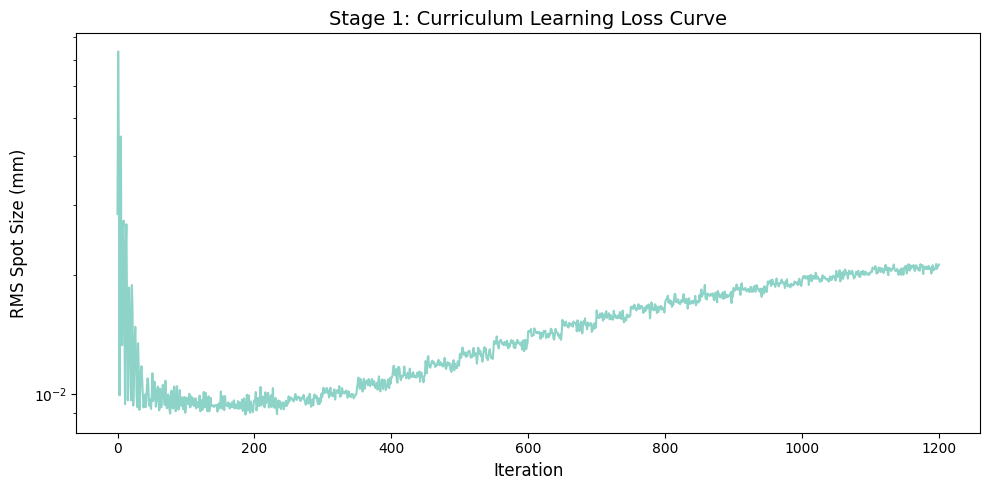

2026-02-07 19:13:29:INFO:lr:[0.0001, 0.0001, 0.001, 0.0001], iterations:1200, num_ring:32, num_arm:8, rays_per_fov:2048.
2026-02-07 19:13:29:INFO:If Out-of-Memory, try to reduce num_ring, num_arm, and rays_per_fov.


Stage 1 - Initial RMS: 0.028547 mm
Stage 1 - Final RMS: 0.021286 mm
Stage 1 - Improvement: 25.4%

Stage 2: Fine-tuning Optimization
Lens design constraints initialized with default values.


Progress:   0%|          | 0/1201 [00:00<?, ?it/s, loss_focus=0, loss_rms=0]

Lens written to ./results/tutorial_0207-184619/fine-tune/iter0.json
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 13.064 um, FoV (0.5) 19.744 um, FoV (1.0) 18.295 um
Geo radius: FoV (0.0) 28.614 um, FoV (0.5) 51.712 um, FoV (1.0) 399.055 um


Progress:   4%|▍         | 50/1201 [00:35<11:33,  1.66it/s, loss_focus=0.00501, loss_gap=1, loss_intersec=-0.798, loss_ray_angle=0, loss_rms=0.0268, loss_surf=0]      

...

Lens written to ./results/tutorial_0207-184619/fine-tune/iter1150.json
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 5.282 um, FoV (0.5) 17.198 um, FoV (1.0) 20.598 um
Geo radius: FoV (0.0) 10.226 um, FoV (0.5) 40.101 um, FoV (1.0) 146.661 um


Progress: 100%|█████████▉| 1200/1201 [13:23<00:00,  1.60it/s, loss_focus=0, loss_gap=1.5, loss_intersec=-0, loss_ray_angle=0, loss_rms=0.0206, loss_surf=0]      

Lens written to ./results/tutorial_0207-184619/fine-tune/iter1200.json
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 5.301 um, FoV (0.5) 17.224 um, FoV (1.0) 20.472 um
Geo radius: FoV (0.0) 10.245 um, FoV (0.5) 40.157 um, FoV (1.0) 138.521 um


Progress: 100%|██████████| 1201/1201 [13:27<00:00,  1.49it/s, loss_focus=0, loss_gap=1.5, loss_intersec=-0, loss_ray_angle=0, loss_rms=0.0206, loss_surf=0]


Stage 2 Fine-tuning complete!


In [7]:
# Visualize Stage 1 loss curve
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(loss_history, linewidth=1.5)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('RMS Spot Size (mm)', fontsize=12)
plt.title('Stage 1: Curriculum Learning Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig(f"{result_dir}/stage1_loss_curve.png", dpi=150, facecolor='white')
plt.show()

print(f"Stage 1 - Initial RMS: {loss_history[0]:.6f} mm")
print(f"Stage 1 - Final RMS: {loss_history[-1]:.6f} mm")
print(f"Stage 1 - Improvement: {(1 - loss_history[-1]/loss_history[0])*100:.1f}%")

# =====> Stage 2: Fine-tuning (same as 2_autolens_rms.py)
# Use smaller learning rates for refinement
print("\n" + "=" * 60)
print("Stage 2: Fine-tuning Optimization")
print("=" * 60)

import os
finetune_dir = f"{result_dir}/fine-tune"
os.makedirs(finetune_dir, exist_ok=True)

# Fine-tune with smaller learning rates (10x smaller)
loss_history_finetune = lens.optimize(
    lrs=[float(lr) * 0.1 for lr in lrs],
    decay=float(decay),
    iterations=iterations,  # Same number of iterations for fine-tuning
    test_per_iter=test_per_iter,
    centroid=False,
    optim_mat=False,  # Don't optimize materials in fine-tuning
    shape_control=True,
    result_dir=finetune_dir,
)

if loss_history_finetune is None:
    print("Warning: Stage 2 returned empty history. Please re-run this cell if needed.")
    loss_history_finetune = []

print("\nStage 2 Fine-tuning complete!")

In [8]:
# =====> Stage 2 Analysis: Loss curve & summary
if loss_history_finetune is None:
    raise RuntimeError("Stage 2 history is None. Please rerun the Stage 2 fine-tuning cell first.")

if len(loss_history_finetune) == 0:
    print("Stage 2 history is empty. Please rerun the Stage 2 fine-tuning cell.")
else:
    # Visualize Stage 2 loss curve
    plt.figure(figsize=(10, 5), facecolor='white')
    plt.plot(loss_history_finetune, linewidth=1.5, color='orange')
    plt.xlabel('Iteration', fontsize=12)
    plt.ylabel('RMS Spot Size (mm)', fontsize=12)
    plt.title('Stage 2: Fine-tuning Loss Curve', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.yscale('log')
    plt.tight_layout()
    plt.savefig(f"{result_dir}/stage2_loss_curve.png", dpi=150, facecolor='white')
    plt.show()

    if 'loss_history' in globals() and len(loss_history) > 0:
        # Combined loss history for later comparison
        loss_history_combined = loss_history + loss_history_finetune
        print(f"\nTotal optimization - Initial RMS: {loss_history[0]:.6f} mm")
        print(f"Total optimization - Final RMS: {loss_history_finetune[-1]:.6f} mm")
        print(f"Total optimization - Improvement: {(1 - loss_history_finetune[-1]/loss_history[0])*100:.1f}%")
    else:
        print("Stage 1 history missing; skipping combined summary.")

Stage 2 history is empty. Please rerun the Stage 2 fine-tuning cell.


## 5. 评估透镜光学指标（PSF、MTF、像差分析）

现在对优化后的透镜进行全面的光学性能评估：

- **PSF (点扩散函数)**: 评估成像锐度
- **MTF (调制传递函数)**: 评估不同空间频率下的对比度传递
- **弥散斑图 (Spot Diagram)**: 可视化各视场的光线分布
- **畸变 (Distortion)**: 评估图像几何失真
- **渐晕 (Vignetting)**: 评估边缘光通量损失

In [9]:
# =====> Stage 3: Final analysis (same as 2_autolens_rms.py)
# Post-processing and final evaluation
lens.prune_surf(expand_factor=0.05)
lens.post_computation()

print("=== Final Optimized Lens Parameters ===")
print(f"Actual: diagonal FOV {np.rad2deg(lens.rfov)*2:.1f}°, r_sensor {lens.r_sensor:.2f}mm, F/{lens.fnum:.2f}")

# Save lens design file
geolens_path = f"{result_dir}/final_lens.json"
lens.write_lens_json(geolens_path)

# Perform comprehensive lens analysis
print("\nPerforming final lens analysis...")
lens.analysis(save_name=f"{result_dir}/final_lens")

=== Final Optimized Lens Parameters ===
Actual: diagonal FOV 79.5°, r_sensor 4.20mm, F/2.02
Lens written to ./results/tutorial_0207-184619/final_lens.json

Performing final lens analysis...
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 5.307 um, FoV (0.5) 17.227 um, FoV (1.0) 20.507 um
Geo radius: FoV (0.0) 10.262 um, FoV (0.5) 40.202 um, FoV (1.0) 145.525 um


In [10]:
# Record refractive lens performance metrics for later comparison
geolens_metrics = {
    'foclen': lens.foclen,
    'fnum': lens.fnum,
    'rfov_deg': np.rad2deg(lens.rfov),
    'final_rms': loss_history_finetune[-1] if loss_history_finetune else loss_history[-1],
}

print("\n" + "=" * 60)
print("Refractive Lens Optical Performance Summary")
print("=" * 60)
print(f"Focal length: {geolens_metrics['foclen']:.2f} mm")
print(f"F-number: {geolens_metrics['fnum']:.2f}")
print(f"Half FOV: {geolens_metrics['rfov_deg']:.2f} deg")
print(f"Final RMS spot size: {geolens_metrics['final_rms']*1000:.2f} um")
print("=" * 60)

# Also export lens to Zemax format
lens.write_lens_zmx(f"{result_dir}/final_lens.zmx")
print(f"\nLens exported to Zemax format: {result_dir}/final_lens.zmx")


Refractive Lens Optical Performance Summary
Focal length: 5.05 mm
F-number: 2.02
Half FOV: 39.74 deg
Final RMS spot size: 21.29 um
Lens written to ./results/tutorial_0207-184619/final_lens.zmx

Lens exported to Zemax format: ./results/tutorial_0207-184619/final_lens.zmx


## 6. 加载优化后的透镜并添加DOE层

现在我们将在优化后的折射透镜基础上添加衍射光学元件（DOE），创建折衍混合透镜系统。

### DOE（衍射光学元件）简介

DOE 利用衍射效应来调制光波的相位，具有以下优势：
- **色差校正**: DOE的色散与折射透镜相反，可有效校正色差
- **轻薄设计**: DOE可以用非常薄的平面元件实现复杂的相位调制
- **可设计性强**: DOE的相位分布可以针对特定应用进行优化

### HybridLens 架构

`HybridLens` 类使用射线-波动混合模型：
1. **折射部分**: 使用可微分光线追踪模拟
2. **衍射部分**: 使用角谱法(ASM)进行波动光学传播

In [11]:
import json

# Read optimized refractive lens data
with open(geolens_path, 'r') as f:
    lens_data = json.load(f)

# Add DOE configuration to lens data
# DOE will be placed after the last lens element, before the sensor
# Note: GeoLens.write_lens_json uses "(d_sensor)" as the key
d_sensor_key = 'd_sensor' if 'd_sensor' in lens_data else '(d_sensor)'
doe_d = lens_data[d_sensor_key] - 0.5  # DOE position from first surface

# DOE configuration (using Binary2 model - radial polynomial phase distribution)
doe_config = {
    "type": "binary2",  # Changed from "DOE" to "binary2" to match supported models
    "d": doe_d,  # DOE position
    "res": [1000, 1000],  # DOE pixel resolution
    "fab_ps": 0.003,  # Fabrication pixel size (mm)
    "is_square": True,
    "param_model": "binary2",  # Radial polynomial model
    "doe_path": None,
    # Initial polynomial coefficients (to be optimized)
    "order2": 0.0,
    "order4": 0.0,
    "order6": 0.0,
    "order8": 0.0,
}

lens_data["DOE"] = doe_config

# Also ensure d_sensor key exists for HybridLens
if 'd_sensor' not in lens_data and '(d_sensor)' in lens_data:
    lens_data['d_sensor'] = lens_data['(d_sensor)']

# Save hybrid lens configuration
hybridlens_init_path = f"{result_dir}/hybridlens_init.json"
with open(hybridlens_init_path, 'w') as f:
    json.dump(lens_data, f, indent=4)

print(f"Hybrid lens configuration saved to: {hybridlens_init_path}")
print(f"\nDOE Configuration:")
print(f"  - Position: {doe_config['d']:.2f} mm")
print(f"  - Resolution: {doe_config['res']}")
print(f"  - Pixel size: {doe_config['fab_ps']*1000:.1f} um")
print(f"  - Phase model: {doe_config['param_model']}")

Hybrid lens configuration saved to: ./results/tutorial_0207-184619/hybridlens_init.json

DOE Configuration:
  - Position: 8.83 mm
  - Resolution: [1000, 1000]
  - Pixel size: 3.0 um
  - Phase model: binary2


In [12]:
# Set double precision for phase calculation accuracy
torch.set_default_dtype(torch.float64)

# Create hybrid refractive-diffractive lens
print("Loading hybrid refractive-diffractive lens...")

# Patch the JSON file if needed (to fix "type": "DOE" issue if previous cell wasn't re-run)
import json
if 'hybridlens_init_path' not in locals():
     # Fallback if variable is missing (e.g. kernel restart)
     hybridlens_init_path = f"{result_dir}/hybridlens_init.json"

if os.path.exists(hybridlens_init_path):
    with open(hybridlens_init_path, 'r') as f:
        data = json.load(f)

    if "DOE" in data and data["DOE"].get("type") in ["DOE", "doe"]:
        print(f"Automatically patching DOE type in {hybridlens_init_path}...")
        data["DOE"]["type"] = "binary2"
        with open(hybridlens_init_path, 'w') as f:
            json.dump(data, f, indent=4)

hybrid_lens = HybridLens(
    filename=hybridlens_init_path,
    dtype=torch.float64
)

# Refocus to infinity
hybrid_lens.refocus(foc_dist=-10000.0)

# ============================================
# 设置 sensor 大小与光圈一致
# ============================================
# 获取光圈半径
aper_r = hybrid_lens.geolens.surfaces[hybrid_lens.geolens.aper_idx].r
# 计算正方形sensor尺寸（边长 = 2 * 光圈半径）
new_sensor_size = (2 * aper_r, 2 * aper_r)
# 保持sensor分辨率的纵横比为1:1
new_sensor_res = (2000, 2000)
# 设置新的sensor尺寸
hybrid_lens.set_sensor(sensor_size=new_sensor_size, sensor_res=new_sensor_res)
# 同步更新geolens的sensor设置
hybrid_lens.geolens.set_sensor(sensor_size=new_sensor_size, sensor_res=new_sensor_res)

print("\n=== Hybrid Lens Parameters ===")
print(f"Refractive part focal length: {hybrid_lens.geolens.foclen:.2f} mm")
print(f"F-number: {hybrid_lens.geolens.fnum:.2f}")
print(f"DOE type: {type(hybrid_lens.doe).__name__}")
print(f"DOE size: {hybrid_lens.doe.w:.2f} x {hybrid_lens.doe.h:.2f} mm")
print(f"Aperture radius: {aper_r:.2f} mm")
print(f"Sensor size (matched to aperture): {new_sensor_size[0]:.2f} x {new_sensor_size[1]:.2f} mm")

Loading hybrid refractive-diffractive lens...
Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
Set torch.float32 as default torch dtype.
Set torch.float64 as default torch dtype.
Failed to calculate distorted FoV by ray tracing, use effective FoV 0.6904988331060259 rad.

=== Hybrid Lens Parameters ===
Refractive part focal length: 5.08 mm
F-number: 2.03
DOE type: Binary2
DOE size: 3.00 x 3.00 mm
Aperture radius: 1.25 mm
Sensor size (matched to aperture): 2.50 x 2.50 mm


## 7. 配置折衍混合透镜优化

配置同时优化折射透镜和DOE的优化器：

- **doe_lr**: DOE相位参数的学习率
- **lens_lr**: 折射透镜参数 [d, c, k, ai] 的学习率
- **PSFLoss**: 用于优化PSF形状的损失函数

In [13]:
# ============================================
# Hybrid Lens Optimization Configuration
# ============================================

# DOE learning rate
doe_lr = 0.1  # Higher learning rate for DOE phase coefficients

# Refractive lens learning rate [d, c, k, ai]
# Use smaller learning rate since refractive part is already optimized
lens_lr = [1e-4, 1e-4, 1e-2, 1e-5]

# Create hybrid lens optimizer
optimizer = hybrid_lens.get_optimizer(
    doe_lr=doe_lr,
    lens_lr=lens_lr,
    lr_decay=0.01
)

# Loss function
loss_fn = PSFLoss()

# Training configuration
hybrid_iterations = 3000 # Number of hybrid lens optimization iterations
test_per_iter = 50

print("=== Hybrid Lens Optimization Configuration ===")
print(f"DOE learning rate: {doe_lr}")
print(f"Lens learning rate: {lens_lr}")
print(f"Number of iterations: {hybrid_iterations}")

=== Hybrid Lens Optimization Configuration ===
DOE learning rate: 0.1
Lens learning rate: [0.0001, 0.0001, 0.01, 1e-05]
Number of iterations: 3000


## 8. 执行折衍混合透镜优化训练

使用 PSFLoss 优化混合透镜的PSF形状。

### 优化流程
1. 计算混合透镜PSF（使用射线-波动混合模型）
2. 计算PSF损失（鼓励紧凑的PSF）
3. 反向传播更新DOE相位参数和透镜参数
4. 定期保存透镜配置和PSF图像

In [14]:
# ============================================
# Hybrid Lens Optimization - Memory Efficient Training
# ============================================
# Strategy: Sequential wavelength optimization with immediate memory cleanup
# This avoids OOM by processing one wavelength at a time

print("=" * 60)
print("Starting Hybrid Refractive-Diffractive Lens Optimization")
print("=" * 60)

# Training configuration
spp = 1000000  # Full SPP as required by HybridLens coherent simulation
ks = 101       # PSF kernel size

# Wavelength configuration
target_wvlns = [0.486, 0.550, 0.630]  # Blue, Green, Red
wvln_weights = [0.25, 0.50, 0.25]     # Weight green more

print(f"SPP: {spp}")
print(f"PSF size: {ks}x{ks}")
print(f"Wavelengths: {target_wvlns}")
print(f"Iterations: {hybrid_iterations}")

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=hybrid_iterations)

# Collect parameters for gradient clipping
all_params = []
for param_group in optimizer.param_groups:
    all_params.extend(param_group['params'])

# Loss history
hybrid_loss_history = []

# Training loop
pbar = tqdm(total=hybrid_iterations + 1, desc="Hybrid Optimization")

for iteration in range(hybrid_iterations + 1):
    optimizer.zero_grad()
    
    total_loss = 0.0
    psf_for_save = None
    
    # =========================================
    # Sequential wavelength processing
    # Process each wavelength separately to manage memory
    # =========================================
    for wvln_idx, (wvln, weight) in enumerate(zip(target_wvlns, wvln_weights)):
        # Compute PSF for this wavelength
        psf = hybrid_lens.psf(
            points=[0.0, 0.0, -10000.0],
            ks=ks,
            wvln=wvln,
            spp=spp
        )
        
        # Compute weighted loss
        loss = loss_fn(psf) * weight
        
        # Backward pass for this wavelength (gradients accumulate)
        loss.backward()
        
        # Record total loss value
        total_loss += loss.item()
        
        # Save green PSF for visualization
        if wvln == 0.550:
            psf_for_save = psf.detach().cpu().clone()
        
        # Immediately release memory
        del psf, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # =========================================
    # Optimizer step
    # =========================================
    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(all_params, max_norm=1.0)
    
    optimizer.step()
    scheduler.step()
    
    hybrid_loss_history.append(total_loss)
    
    # =========================================
    # Periodic evaluation and saving
    # =========================================
    if iteration % test_per_iter == 0:
        with torch.no_grad():
            # Save lens configuration
            hybrid_lens.write_lens_json(f"{result_dir}/hybrid_iter{iteration}.json")
            
            # Save green PSF image
            if psf_for_save is not None:
                save_image(
                    psf_for_save.unsqueeze(0).unsqueeze(0),
                    f"{result_dir}/hybrid_psf_iter{iteration}.png",
                    normalize=True
                )
            
            # Generate RGB PSF composite (sequentially to save memory)
            psf_channels = []
            for wvln in target_wvlns:
                psf_ch = hybrid_lens.psf(
                    points=[0.0, 0.0, -10000.0],
                    ks=ks,
                    wvln=wvln,
                    spp=spp
                )
                psf_channels.append(psf_ch.detach().cpu())
                del psf_ch
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            
            # Stack RGB (Red=630nm, Green=550nm, Blue=486nm)
            psf_rgb = torch.stack([psf_channels[2], psf_channels[1], psf_channels[0]], dim=0)
            save_image(
                psf_rgb.unsqueeze(0),
                f"{result_dir}/hybrid_psf_rgb_iter{iteration}.png",
                normalize=True
            )
            del psf_channels, psf_rgb
            
            # Draw layout
            try:
                hybrid_lens.draw_layout(save_name=f"{result_dir}/hybrid_layout_iter{iteration}.png")
            except (ValueError, RuntimeError) as e:
                pass  # Skip if layout drawing fails
            
            # Print progress
            current_lr = scheduler.get_last_lr()[0]
            print(f"\nIter {iteration}: loss={total_loss:.6f}, lr={current_lr:.2e}")
            
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    # Update progress bar
    pbar.set_postfix({"loss": f"{total_loss:.4f}"})
    pbar.update(1)
    
    # Clean up saved PSF
    del psf_for_save

pbar.close()

print("\n" + "=" * 60)
print("Hybrid lens optimization complete!")
print(f"Initial loss: {hybrid_loss_history[0]:.6f}")
print(f"Final loss: {hybrid_loss_history[-1]:.6f}")
print(f"Improvement: {(1 - hybrid_loss_history[-1]/hybrid_loss_history[0])*100:.1f}%")
print("=" * 60)

Starting Hybrid Refractive-Diffractive Lens Optimization
SPP: 1000000
PSF size: 101x101
Wavelengths: [0.486, 0.55, 0.63]
Iterations: 3000


Hybrid Optimization:   0%|          | 0/3001 [00:00<?, ?it/s]

Hybrid Optimization:   0%|          | 1/3001 [00:02<1:57:49,  2.36s/it, loss=0.0261]


Iter 0: loss=0.026145, lr=1.00e-04


Hybrid Optimization:   2%|▏         | 51/3001 [00:54<1:06:45,  1.36s/it, loss=0.0240]

...


Iter 2900: loss=0.014338, lr=2.68e-07


Hybrid Optimization:  98%|█████████▊| 2951/3001 [48:45<01:03,  1.28s/it, loss=0.0144]


Iter 2950: loss=0.014364, lr=6.58e-08


Hybrid Optimization: 100%|██████████| 3001/3001 [49:35<00:00,  1.01it/s, loss=0.0143]


Iter 3000: loss=0.014280, lr=2.74e-11

Hybrid lens optimization complete!
Initial loss: 0.026145
Final loss: 0.014280
Improvement: 45.4%


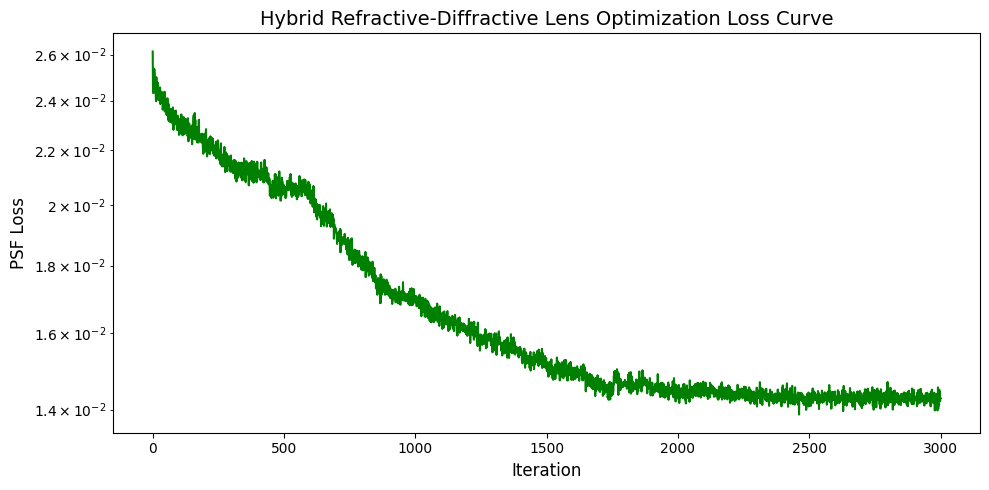

Initial PSF Loss: 0.026145
Final PSF Loss: 0.014280
Improvement: 45.4%


In [15]:
# Visualize hybrid lens optimization loss curve
plt.figure(figsize=(10, 5), facecolor='white')
plt.plot(hybrid_loss_history, linewidth=1.5, color='green')
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('PSF Loss', fontsize=12)
plt.title('Hybrid Refractive-Diffractive Lens Optimization Loss Curve', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.tight_layout()
plt.savefig(f"{result_dir}/hybrid_loss_curve.png", dpi=150, facecolor='white')
plt.show()

print(f"Initial PSF Loss: {hybrid_loss_history[0]:.6f}")
print(f"Final PSF Loss: {hybrid_loss_history[-1]:.6f}")
print(f"Improvement: {(1 - hybrid_loss_history[-1]/hybrid_loss_history[0])*100:.1f}%")

## 9. 端到端优化：混合透镜 + UNet后处理网络

在完成折衍混合透镜优化后，我们添加一个UNet神经网络作为后处理模块，进行端到端联合优化。

### 端到端优化的优势

1. **联合优化**: 同时优化光学系统（折射透镜+DOE）和后处理网络
2. **系统协同**: 光学设计和计算后处理可以相互补偿，达到更好的整体性能
3. **任务驱动**: 针对特定任务（如图像重建）进行联合优化

### 网络选择

使用DeepLens内置的UNet网络，参数规模适中，适合端到端训练：
- 输入: 混合透镜渲染的退化图像
- 输出: 重建的清晰图像

In [18]:
# ============================================
# 端到端优化配置
# ============================================

# 导入UNet和数据集
from deeplens.network import UNet
from deeplens.network.dataset import ImageDataset
from torch.utils.data import DataLoader
from deeplens.utils import (
    batch_PSNR,
    batch_SSIM,
    denormalize_ImageNet,
    normalize_ImageNet,
 )

# 切换回float32以适配网络训练
torch.set_default_dtype(torch.float32)
hybrid_lens.astype(torch.float32)

# 设置图像分辨率（需要能被16整除以适配UNet）
img_res = (512, 512)
hybrid_lens.set_sensor_res(sensor_res=img_res)

# 创建UNet网络
net = UNet(in_channels=3, out_channels=3)
net = net.to(device)

print("=== 端到端优化配置 ===")
print(f"图像分辨率: {img_res}")
print(f"网络参数量: {sum(p.numel() for p in net.parameters()):,}")
print(f"设备: {device}")

=== 端到端优化配置 ===
图像分辨率: (512, 512)
网络参数量: 10,788,547
设备: cuda


In [19]:
# ============================================
# 准备训练数据集
# ============================================

# 检查并下载数据集
train_dir = "./datasets/BSDS300/images/train"
if not os.path.exists(train_dir):
    print("下载BSDS300数据集...")
    from deeplens.network.dataset import download_bsd300
    download_bsd300("./datasets")
else:
    print(f"使用已有数据集: {train_dir}")

# 创建数据加载器
train_set = ImageDataset(train_dir, img_res)
train_loader = DataLoader(train_set, batch_size=2, shuffle=True, num_workers=0)

print(f"数据集大小: {len(train_set)}")
print(f"Batch数量: {len(train_loader)}")

下载BSDS300数据集...
downloading url  http://www2.eecs.berkeley.edu/Research/Projects/CS/vision/bsds/BSDS300-images.tgz
Extracting data
数据集大小: 200
Batch数量: 100


In [25]:
# ============================================
# 端到端联合训练
# ============================================

# 训练配置
e2e_epochs = 1000 # 训练轮数
e2e_lr_net = 1e-4  # 网络学习率
e2e_lr_doe = 0.01  # DOE学习率
e2e_lr_lens = [1e-5, 1e-5, 1e-4, 1e-6]  # 透镜学习率 [d, c, k, ai]

# Helper to rebuild non-leaf tensors after dtype casting
def _replace_tensor_attr(obj, old, new):
    for key, val in vars(obj).items():
        if val is old:
            setattr(obj, key, new)
            return True
        if isinstance(val, list):
            for i, v in enumerate(val):
                if v is old:
                    val[i] = new
                    return True
        if isinstance(val, tuple):
            for i, v in enumerate(val):
                if v is old:
                    new_list = list(val)
                    new_list[i] = new
                    setattr(obj, key, tuple(new_list))
                    return True
    return False

def _normalize_params(params):
    if isinstance(params, torch.Tensor):
        return [params]
    if isinstance(params, (list, tuple)):
        return list(params)
    return [params]

def _releaf_param_groups(param_groups, roots):
    for group in param_groups:
        params = _normalize_params(group.get("params", []))
        new_params = []
        for p in params:
            if isinstance(p, torch.Tensor) and not p.is_leaf:
                new_p = p.detach().clone().requires_grad_(True)
                for root in roots:
                    if _replace_tensor_attr(root, p, new_p):
                        break
                new_params.append(new_p)
            else:
                new_params.append(p)
        group["params"] = new_params
    return param_groups

# 创建优化器
# 网络优化器
net_optim = torch.optim.AdamW(net.parameters(), lr=e2e_lr_net, betas=(0.9, 0.98))

# 混合透镜优化器（DOE + 折射透镜）
lens_param_groups = []
lens_param_groups += hybrid_lens.geolens.get_optimizer_params(
    lrs=e2e_lr_lens, decay=0.01, optim_mat=False
 )
lens_param_groups += hybrid_lens.doe.get_optimizer_params(lr=e2e_lr_doe)

roots = [hybrid_lens.geolens, hybrid_lens.doe] + list(hybrid_lens.geolens.surfaces)
lens_param_groups = _releaf_param_groups(lens_param_groups, roots)
lens_optim = torch.optim.Adam(lens_param_groups)

# 学习率调度器
total_steps = e2e_epochs * len(train_loader)
net_sche = torch.optim.lr_scheduler.CosineAnnealingLR(net_optim, T_max=total_steps)
lens_sche = torch.optim.lr_scheduler.CosineAnnealingLR(lens_optim, T_max=total_steps)

# 损失函数
cri_l1 = nn.L1Loss()

print("=== 端到端训练配置 ===")
print(f"训练轮数: {e2e_epochs}")
print(f"总步数: {total_steps}")
print(f"网络学习率: {e2e_lr_net}")
print(f"DOE学习率: {e2e_lr_doe}")
print(f"透镜学习率: {e2e_lr_lens}")

=== 端到端训练配置 ===
训练轮数: 1000
总步数: 100000
网络学习率: 0.0001
DOE学习率: 0.01
透镜学习率: [1e-05, 1e-05, 0.0001, 1e-06]


In [31]:
# ============================================
# 执行端到端训练
# ============================================

import torch.nn.functional as F

print("=" * 60)
print("开始端到端联合优化: 混合透镜 + UNet")
print("=" * 60)

e2e_loss_history = []
e2e_psnr_history = []

# HybridLens coherent PSF requires spp >= 1_000_000
e2e_spp = 1_000_000

# Early stopping (patience in epochs)
early_stop_patience = 50
best_loss = float("inf")
no_improve_epochs = 0

# 保存初始状态
hybrid_lens.write_lens_json(f"{result_dir}/e2e_epoch0.json")

def _psf_float64(lens, **kwargs):
    prev_dtype = torch.get_default_dtype()
    torch.set_default_dtype(torch.float64)
    try:
        return lens.psf(**kwargs)
    finally:
        torch.set_default_dtype(prev_dtype)

for epoch in range(e2e_epochs):
    epoch_loss = 0.0
    net.train()
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{e2e_epochs}")
    for batch_idx, img_org in enumerate(pbar):
        img_org = img_org.to(device)
        
        # ===== 前向传播 =====
        # 1. 混合透镜渲染（使用render方法）
        with torch.no_grad():
            # 简化渲染：使用PSF卷积
            # 获取中心PSF用于简化渲染
            psf = _psf_float64(
                hybrid_lens,
                points=[0.0, 0.0, -10000.0],
                ks=31,
                wvln=0.55,
                spp=e2e_spp
            )
            psf = psf.float()
            # 确保PSF和为1
            psf = psf / (psf.sum() + 1e-8)
            
        # PSF卷积渲染
        psf_kernel = psf.unsqueeze(0).unsqueeze(0)  # [1, 1, ks, ks]
        psf_kernel = psf_kernel.expand(3, 1, -1, -1)  # [3, 1, ks, ks]
        
        pad_size = psf_kernel.shape[-1] // 2
        img_padded = F.pad(img_org, [pad_size]*4, mode='reflect')
        img_render = F.conv2d(img_padded, psf_kernel, groups=3)
        
        # 添加少量噪声模拟真实成像
        img_render = img_render + torch.randn_like(img_render) * 0.01
        img_render = torch.clamp(img_render, 0, 1)
        
        # 2. 网络重建
        img_rec = net(img_render)
        img_rec = torch.clamp(img_rec, 0, 1)
        
        # ===== 计算损失 =====
        L_rec = cri_l1(img_rec, img_org)
        
        # ===== 反向传播 =====
        net_optim.zero_grad()
        lens_optim.zero_grad()
        
        L_rec.backward()
        
        # 梯度裁剪
        torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=1.0)
        
        net_optim.step()
        lens_optim.step()
        
        net_sche.step()
        lens_sche.step()
        
        epoch_loss += L_rec.item()
        pbar.set_postfix({"loss": f"{L_rec.item():.4f}"})
    
    # 记录epoch损失
    avg_loss = epoch_loss / len(train_loader)
    e2e_loss_history.append(avg_loss)
    
    # Early stopping update
    if avg_loss < best_loss - 1e-6:
        best_loss = avg_loss
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
        if no_improve_epochs >= early_stop_patience:
            print(f"\nEarly stopping at epoch {epoch+1} (patience {early_stop_patience}).")
            break
    
    # 每5个epoch评估一次
    if (epoch + 1) % 5 == 0:
        net.eval()
        with torch.no_grad():
            # 加载测试图像
            test_img_path = "./datasets/charts/NBS_1963_1k.png"
            if os.path.exists(test_img_path):
                test_img = Image.open(test_img_path).convert('RGB')
                test_img = test_img.resize(img_res)
                test_img = np.array(test_img).astype(np.float32) / 255.0
                test_img = torch.from_numpy(test_img).permute(2, 0, 1).unsqueeze(0).to(device)
                
                # 渲染
                psf = _psf_float64(
                    hybrid_lens,
                    points=[0.0, 0.0, -10000.0],
                    ks=31,
                    wvln=0.55,
                    spp=e2e_spp
                ).float()
                psf = psf / (psf.sum() + 1e-8)
                psf_kernel = psf.unsqueeze(0).unsqueeze(0).expand(3, 1, -1, -1)
                pad_size = psf_kernel.shape[-1] // 2
                test_padded = F.pad(test_img, [pad_size]*4, mode='reflect')
                test_render = F.conv2d(test_padded, psf_kernel, groups=3)
                
                # 重建
                test_rec = net(test_render)
                test_rec = torch.clamp(test_rec, 0, 1)
                
                # 计算PSNR
                psnr = batch_PSNR(test_img, test_rec)
                e2e_psnr_history.append(psnr)
                
                # 保存结果
                save_image(test_render, f"{result_dir}/e2e_render_epoch{epoch+1}.png")
                save_image(test_rec, f"{result_dir}/e2e_rec_epoch{epoch+1}.png")
                
                print(f"\nEpoch {epoch+1}: Loss={avg_loss:.4f}, PSNR={psnr:.2f}dB")
        
        # 保存模型
        hybrid_lens.write_lens_json(f"{result_dir}/e2e_epoch{epoch+1}.json")
        torch.save(net.state_dict(), f"{result_dir}/e2e_net_epoch{epoch+1}.pth")

print("\n" + "=" * 60)
print("端到端训练完成!")
print(f"最终Loss: {e2e_loss_history[-1]:.4f}")
if e2e_psnr_history:
    print(f"最终PSNR: {e2e_psnr_history[-1]:.2f}dB")
print("=" * 60)

开始端到端联合优化: 混合透镜 + UNet


Epoch 1/1000:  43%|████▎     | 43/100 [00:12<00:16,  3.48it/s, loss=0.8333]

Epoch 5/1000: 100%|██████████| 100/100 [00:28<00:00,  3.47it/s, loss=0.8956]



Epoch 5: Loss=0.6815, PSNR=17.30dB


Epoch 10/1000: 100%|██████████| 100/100 [00:28<00:00,  3.47it/s, loss=0.6817]


...


Epoch 55: Loss=0.6741, PSNR=19.28dB


Epoch 60/1000: 100%|██████████| 100/100 [00:28<00:00,  3.46it/s, loss=0.4031]



Epoch 60: Loss=0.6408, PSNR=19.62dB


Epoch 62/1000: 100%|██████████| 100/100 [00:29<00:00,  3.44it/s, loss=0.6453]


Early stopping at epoch 62 (patience 50).

端到端训练完成!
最终Loss: 0.6571
最终PSNR: 19.62dB


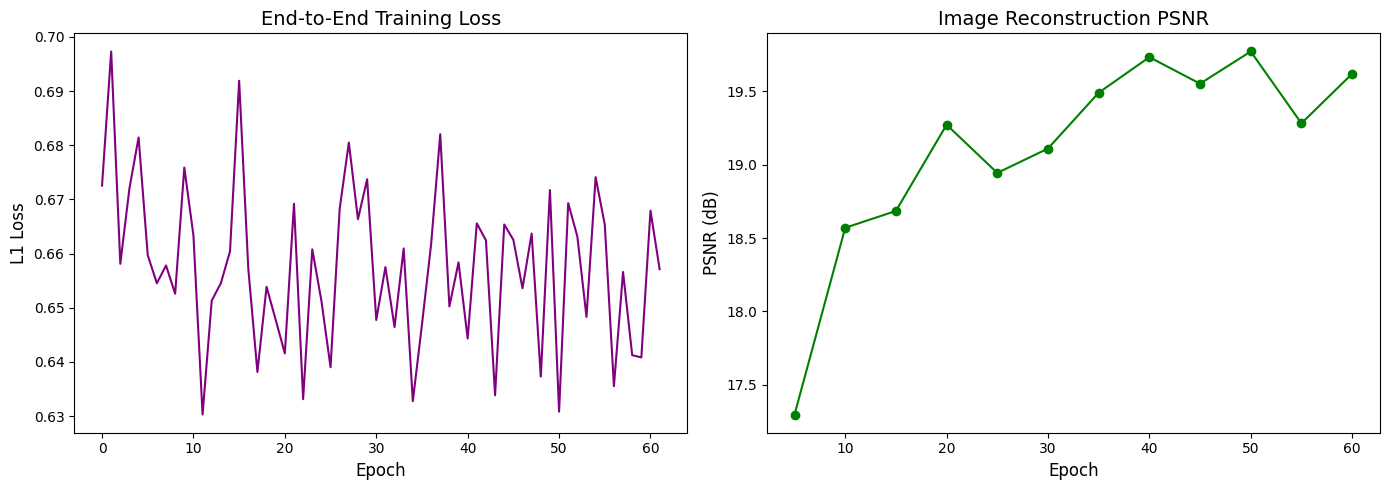

端到端训练 - 初始Loss: 0.6726
端到端训练 - 最终Loss: 0.6571
端到端训练 - 初始PSNR: 17.30dB
端到端训练 - 最终PSNR: 19.62dB


In [32]:
# ============================================
# 可视化端到端训练结果
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Loss曲线
axes[0].plot(e2e_loss_history, linewidth=1.5, color='purple')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('L1 Loss', fontsize=12)
axes[0].set_title('End-to-End Training Loss', fontsize=14)
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('white')

# PSNR曲线
if e2e_psnr_history:
    epochs_eval = list(range(5, e2e_epochs + 1, 5))
    axes[1].plot(epochs_eval[:len(e2e_psnr_history)], e2e_psnr_history, 
                 linewidth=1.5, color='green', marker='o')
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('PSNR (dB)', fontsize=12)
    axes[1].set_title('Image Reconstruction PSNR', fontsize=14)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_facecolor('white')

plt.tight_layout()
plt.savefig(f"{result_dir}/e2e_training_curves.png", dpi=150, facecolor='white')
plt.show()

print(f"端到端训练 - 初始Loss: {e2e_loss_history[0]:.4f}")
print(f"端到端训练 - 最终Loss: {e2e_loss_history[-1]:.4f}")
if e2e_psnr_history:
    print(f"端到端训练 - 初始PSNR: {e2e_psnr_history[0]:.2f}dB")
    print(f"端到端训练 - 最终PSNR: {e2e_psnr_history[-1]:.2f}dB")

## 10. 超表面混合透镜设计 (Metasurface Hybrid Lens)

本节使用Pixel2D参数化的超表面（Metasurface）代替DOE，实现更灵活的相位调制。

### 超表面 vs DOE

| 特性 | DOE (Binary2) | 超表面 (Pixel2D) |
|------|---------------|------------------|
| 参数化 | 径向多项式系数 | 每个像素独立相位 |
| 自由度 | 低（几个系数） | 高（百万像素） |
| 优化难度 | 简单 | 需要正则化 |
| 设计灵活性 | 受限于多项式 | 任意相位分布 |
| 制造工艺 | 传统光刻 | 纳米压印/光刻 |

### Pixel2D 超表面

`Pixel2D` 类允许每个像素拥有独立的相位值，可以实现任意复杂的相位分布：
- 更强的像差校正能力
- 可实现非传统光学功能（如涡旋光束、多焦点等）
- 需要更多的正则化以避免过拟合

In [44]:
# ============================================
# 创建超表面混合透镜配置
# ============================================
import json

# 重新加载优化后的折射透镜
with open(geolens_path, 'r') as f:
    lens_data_meta = json.load(f)

# 获取sensor距离
d_sensor_key_meta = 'd_sensor' if 'd_sensor' in lens_data_meta else '(d_sensor)'
meta_d = lens_data_meta[d_sensor_key_meta] - 0.3  # 超表面位置

# 超表面配置 (使用Pixel2D)
meta_res = (300, 300)  # 超表面分辨率（降低以节省显存）
meta_config = {
    "type": "pixel2d",  # 使用Pixel2D超表面
    "d": meta_d,
    "res": list(meta_res),
    "fab_ps": 0.004,  # 制造像素尺寸 4um
    "fab_step": 16,
    "mat": "fused_silica",
    "wvln0": 0.55,
    "phase_map_path": None,  # 初始化随机相位
}

lens_data_meta["DOE"] = meta_config

# 确保d_sensor存在
if 'd_sensor' not in lens_data_meta and '(d_sensor)' in lens_data_meta:
    lens_data_meta['d_sensor'] = lens_data_meta['(d_sensor)']

# 保存超表面混合透镜配置
metalens_init_path = f"{result_dir}/metalens_init.json"
with open(metalens_init_path, 'w') as f:
    json.dump(lens_data_meta, f, indent=4)

print(f"超表面混合透镜配置已保存: {metalens_init_path}")
print(f"\n超表面配置:")
print(f"  - 位置: {meta_config['d']:.2f} mm")
print(f"  - 分辨率: {meta_config['res']}")
print(f"  - 像素尺寸: {meta_config['fab_ps']*1000:.1f} um")
print(f"  - 类型: {meta_config['type']}")

超表面混合透镜配置已保存: ./results/tutorial_0207-184619/metalens_init.json

超表面配置:
  - 位置: 9.03 mm
  - 分辨率: [300, 300]
  - 像素尺寸: 4.0 um
  - 类型: pixel2d


In [53]:
# ============================================
# 加载超表面混合透镜
# ============================================

import gc

# 尽量释放GPU显存，避免初始化时OOM
if torch.cuda.is_available():
    if 'hybrid_lens' in locals():
        try:
            hybrid_lens.to('cpu')
        except (AttributeError, RuntimeError):
            pass
    if 'net' in locals():
        net.to('cpu')
    if 'meta_lens' in locals():
        del meta_lens
    gc.collect()
    torch.cuda.empty_cache()

# 使用双精度进行相位计算
torch.set_default_dtype(torch.float64)

print("加载超表面混合透镜...")
meta_lens = HybridLens(
    filename=metalens_init_path,
    dtype=torch.float64
 )

# Patch Pixel2D.surf_dict to include a valid phase_map_path for write_lens_json
if hasattr(meta_lens, "doe") and hasattr(meta_lens.doe, "surf_dict"):
    _doe_surf_dict_impl = meta_lens.doe.surf_dict
    def _doe_surf_dict_wrapper(phase_map_path=None, _impl=_doe_surf_dict_impl):
        if not phase_map_path:
            phase_map_path = os.path.join(result_dir, "meta_phase_map.pt")
        os.makedirs(os.path.dirname(phase_map_path), exist_ok=True)
        return _impl(phase_map_path)
    meta_lens.doe.surf_dict = _doe_surf_dict_wrapper

# 重新聚焦到无穷远
meta_lens.refocus(foc_dist=-10000.0)

# 设置sensor
aper_r_meta = meta_lens.geolens.surfaces[meta_lens.geolens.aper_idx].r
meta_sensor_size = (2 * aper_r_meta, 2 * aper_r_meta)
meta_sensor_res = (900, 900)
meta_lens.set_sensor(sensor_size=meta_sensor_size, sensor_res=meta_sensor_res)
meta_lens.geolens.set_sensor(sensor_size=meta_sensor_size, sensor_res=meta_sensor_res)

print("\n=== 超表面混合透镜参数 ===")
print(f"折射透镜焦距: {meta_lens.geolens.foclen:.2f} mm")
print(f"F数: {meta_lens.geolens.fnum:.2f}")
print(f"超表面类型: {type(meta_lens.doe).__name__}")
print(f"超表面分辨率: {meta_lens.doe.res}")
print(f"传感器尺寸: {meta_sensor_size[0]:.2f} x {meta_sensor_size[1]:.2f} mm")

加载超表面混合透镜...
Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
Set torch.float32 as default torch dtype.
Set torch.float64 as default torch dtype.
Failed to calculate distorted FoV by ray tracing, use effective FoV 0.690263558095527 rad.
Failed to calculate distorted FoV by ray tracing, use effective FoV 0.33490092870947047 rad.

=== 超表面混合透镜参数 ===
折射透镜焦距: 5.08 mm
F数: 2.03
超表面类型: Pixel2D
超表面分辨率: [300, 300]
传感器尺寸: 2.50 x 2.50 mm


In [55]:
# ============================================
# 超表面混合透镜优化
# ============================================

# 优化配置
meta_lr = 0.005  # 超表面学习率（需要较小以避免振荡）
meta_lens_lr = [1e-5, 1e-5, 1e-3, 1e-6]  # 透镜学习率
meta_iterations = 1000  # 迭代次数
meta_test_per_iter = 50

# 创建优化器
meta_optimizer = meta_lens.get_optimizer(
    doe_lr=meta_lr,
    lens_lr=meta_lens_lr,
    lr_decay=0.01
)

# 学习率调度器
meta_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    meta_optimizer, T_max=meta_iterations
)

# 收集参数用于梯度裁剪
meta_params = []
for param_group in meta_optimizer.param_groups:
    meta_params.extend(param_group['params'])

print("=== 超表面优化配置 ===")
print(f"超表面学习率: {meta_lr}")
print(f"透镜学习率: {meta_lens_lr}")
print(f"迭代次数: {meta_iterations}")

=== 超表面优化配置 ===
超表面学习率: 0.005
透镜学习率: [1e-05, 1e-05, 0.001, 1e-06]
迭代次数: 1000


In [56]:
# ============================================
# 执行超表面混合透镜训练
# ============================================

print("=" * 60)
print("开始超表面混合透镜优化")
print("=" * 60)

# 训练配置
meta_spp = 1000000
meta_ks = 51
meta_wvlns = [0.486, 0.550, 0.630]
meta_weights = [0.25, 0.50, 0.25]

meta_loss_history = []

if torch.cuda.is_available():
    torch.cuda.empty_cache()

pbar = tqdm(total=meta_iterations + 1, desc="Metasurface Optimization")

for iteration in range(meta_iterations + 1):
    meta_optimizer.zero_grad()
    
    total_loss = 0.0
    psf_save = None
    
    # 顺序处理每个波长
    for wvln_idx, (wvln, weight) in enumerate(zip(meta_wvlns, meta_weights)):
        psf = meta_lens.psf(
            points=[0.0, 0.0, -10000.0],
            ks=meta_ks,
            wvln=wvln,
            spp=meta_spp
        )
        
        # 计算损失
        loss = loss_fn(psf) * weight
        loss.backward()
        
        total_loss += loss.item()
        
        if wvln == 0.550:
            psf_save = psf.detach().cpu().clone()
        
        del psf, loss
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # 添加相位平滑正则化
    if hasattr(meta_lens.doe, 'phase_map'):
        phase_map = meta_lens.doe.phase_map
        # 计算相位梯度（鼓励平滑）
        dx = phase_map[1:, :] - phase_map[:-1, :]
        dy = phase_map[:, 1:] - phase_map[:, :-1]
        reg_smooth = 0.001 * (dx.abs().mean() + dy.abs().mean())
        reg_smooth.backward()
        total_loss += reg_smooth.item()
    
    # 梯度裁剪和优化步骤
    torch.nn.utils.clip_grad_norm_(meta_params, max_norm=1.0)
    meta_optimizer.step()
    meta_scheduler.step()
    
    meta_loss_history.append(total_loss)
    
    # 定期评估
    if iteration % meta_test_per_iter == 0:
        with torch.no_grad():
            meta_lens.write_lens_json(f"{result_dir}/meta_iter{iteration}.json")
            
            if psf_save is not None:
                save_image(
                    psf_save.unsqueeze(0).unsqueeze(0),
                    f"{result_dir}/meta_psf_iter{iteration}.png",
                    normalize=True
                )
            
            # 保存RGB PSF
            psf_channels = []
            for wvln in meta_wvlns:
                psf_ch = meta_lens.psf(
                    points=[0.0, 0.0, -10000.0],
                    ks=meta_ks,
                    wvln=wvln,
                    spp=meta_spp
                )
                psf_channels.append(psf_ch.detach().cpu())
                del psf_ch
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
            
            psf_rgb = torch.stack([psf_channels[2], psf_channels[1], psf_channels[0]], dim=0)
            save_image(
                psf_rgb.unsqueeze(0),
                f"{result_dir}/meta_psf_rgb_iter{iteration}.png",
                normalize=True
            )
            del psf_channels, psf_rgb
            
            current_lr = meta_scheduler.get_last_lr()[0]
            print(f"\nIter {iteration}: loss={total_loss:.6f}, lr={current_lr:.2e}")
            
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    pbar.set_postfix({"loss": f"{total_loss:.4f}"})
    pbar.update(1)
    
    del psf_save

pbar.close()

print("\n" + "=" * 60)
print("超表面混合透镜优化完成!")
print(f"初始损失: {meta_loss_history[0]:.6f}")
print(f"最终损失: {meta_loss_history[-1]:.6f}")
print(f"改进: {(1 - meta_loss_history[-1]/meta_loss_history[0])*100:.1f}%")
print("=" * 60)

开始超表面混合透镜优化


Metasurface Optimization:   0%|          | 1/1001 [00:01<23:47,  1.43s/it, loss=0.0743]


Iter 0: loss=0.074265, lr=1.00e-05


Metasurface Optimization:   5%|▌         | 51/1001 [00:49<18:06,  1.14s/it, loss=0.0818]


Iter 50: loss=0.081819, lr=9.94e-06


...


Iter 900: loss=0.062131, lr=2.40e-07


Metasurface Optimization:  95%|█████████▌| 951/1001 [15:28<00:55,  1.10s/it, loss=0.0624]


Iter 950: loss=0.062409, lr=5.91e-08


Metasurface Optimization: 100%|██████████| 1001/1001 [16:14<00:00,  1.03it/s, loss=0.0567]


Iter 1000: loss=0.056687, lr=2.47e-11

超表面混合透镜优化完成!
初始损失: 0.074265
最终损失: 0.056687
改进: 23.7%


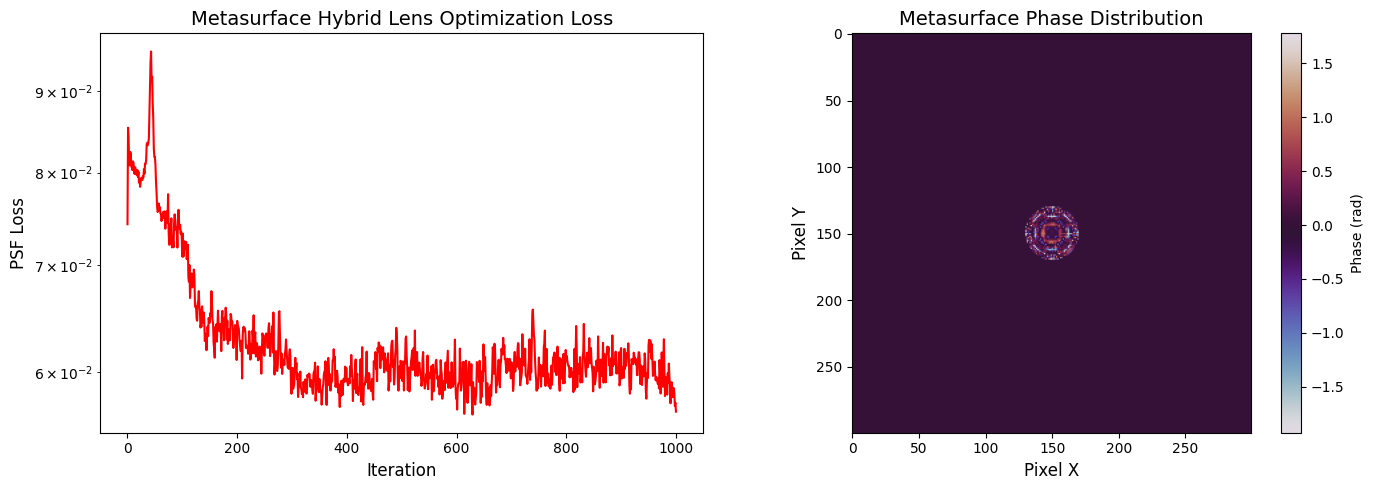


超表面相位图已保存
初始PSF损失: 0.074265
最终PSF损失: 0.056687


In [57]:
# ============================================
# 可视化超表面优化结果
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Loss曲线
axes[0].plot(meta_loss_history, linewidth=1.5, color='red')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('PSF Loss', fontsize=12)
axes[0].set_title('Metasurface Hybrid Lens Optimization Loss', fontsize=14)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3)
axes[0].set_facecolor('white')

# 显示超表面相位分布
if hasattr(meta_lens.doe, 'phase_map'):
    phase_np = meta_lens.doe.phase_map.detach().cpu().numpy()
    im = axes[1].imshow(phase_np, cmap='twilight', aspect='equal')
    axes[1].set_title('Metasurface Phase Distribution', fontsize=14)
    axes[1].set_xlabel('Pixel X', fontsize=12)
    axes[1].set_ylabel('Pixel Y', fontsize=12)
    plt.colorbar(im, ax=axes[1], label='Phase (rad)')
else:
    axes[1].text(0.5, 0.5, 'Phase map not available', ha='center', va='center')

plt.tight_layout()
plt.savefig(f"{result_dir}/meta_optimization_results.png", dpi=150, facecolor='white')
plt.show()

# 保存最终超表面配置
meta_lens.write_lens_json(f"{result_dir}/metalens_final.json")
print(f"\n超表面相位图已保存")
print(f"初始PSF损失: {meta_loss_history[0]:.6f}")
print(f"最终PSF损失: {meta_loss_history[-1]:.6f}")

## 11. 独立测试模块 (Standalone Testing)

本节提供独立的测试功能，可以直接加载已保存的透镜和模型进行测试，无需重新训练。

### 测试模式选择

- **模式 A**: 测试折射透镜 (GeoLens)
- **模式 B**: 测试DOE混合透镜 (HybridLens with Binary2)
- **模式 C**: 测试超表面混合透镜 (HybridLens with Pixel2D)
- **模式 D**: 测试端到端系统 (混合透镜 + UNet)

### 使用方法

1. 设置 `TEST_MODE` 选择测试模式
2. 设置 `TEST_LENS_PATH` 指向要测试的透镜文件
3. 运行测试单元格

In [68]:
# ============================================
# 独立测试配置 - 可直接运行无需前置训练
# ============================================

# ===========================================
# 测试模式选择 (修改此处选择测试内容)
# ===========================================
TEST_MODE = "D"  # 可选: "A" (折射), "B" (DOE混合), "C" (超表面), "D" (端到端)

# ===========================================
# 测试路径配置 (修改为你的透镜文件路径)
# ===========================================
# 示例路径 - 请根据实际情况修改
TEST_PATHS = {
    "A": {
        "lens": "./results/tutorial_0207-184619/final_lens.json",  # 折射透镜
        "desc": "纯折射透镜 (GeoLens)"
    },
    "B": {
        "lens": "./results/tutorial_0207-184619/hybrid_final.json",  # DOE混合透镜
        "desc": "DOE混合透镜 (Binary2)"
    },
    "C": {
        "lens": "./results/tutorial_0207-184619/metalens_final.json",  # 超表面混合
        "desc": "超表面混合透镜 (Pixel2D)"
    },
    "D": {
        "lens": "./results/tutorial_0207-184619/e2e_epoch50.json",  # 端到端透镜
        "net": "./results/tutorial_0207-184619/e2e_net_epoch50.pth",  # UNet权重
        "desc": "端到端系统 (HybridLens + UNet)"
    }
}

# 测试图像路径
TEST_IMAGE_PATH = "./datasets/charts/NBS_1963_1k.png"

# 或者使用当前结果目录（如果存在）
if 'result_dir' in dir() and os.path.exists(result_dir):
    print(f"检测到当前训练结果目录: {result_dir}")
    # 自动更新路径
    if os.path.exists(f"{result_dir}/final_lens.json"):
        TEST_PATHS["A"]["lens"] = f"{result_dir}/final_lens.json"
    if os.path.exists(f"{result_dir}/hybrid_final.json"):
        TEST_PATHS["B"]["lens"] = f"{result_dir}/hybrid_final.json"
    if os.path.exists(f"{result_dir}/metalens_final.json"):
        TEST_PATHS["C"]["lens"] = f"{result_dir}/metalens_final.json"
    # 查找最新的端到端模型
    e2e_files = [f for f in os.listdir(result_dir) if f.startswith("e2e_net_epoch") and f.endswith(".pth")]
    if e2e_files:
        latest_e2e = sorted(e2e_files, key=lambda x: int(x.split("epoch")[1].split(".")[0]))[-1]
        epoch_num = latest_e2e.split("epoch")[1].split(".")[0]
        TEST_PATHS["D"]["lens"] = f"{result_dir}/e2e_epoch{epoch_num}.json"
        TEST_PATHS["D"]["net"] = f"{result_dir}/{latest_e2e}"

print(f"\n当前测试模式: {TEST_MODE}")
print(f"测试类型: {TEST_PATHS[TEST_MODE]['desc']}")
print(f"透镜路径: {TEST_PATHS[TEST_MODE]['lens']}")

检测到当前训练结果目录: ./results/tutorial_0207-184619

当前测试模式: D
测试类型: 端到端系统 (HybridLens + UNet)
透镜路径: ./results/tutorial_0207-184619/e2e_epoch60.json


In [69]:
# ============================================
# 独立测试初始化 - 确保必要的导入和设备设置
# ============================================

# 确保必要的导入（可独立运行）
import os
import json
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from torchvision.utils import save_image

# 尝试导入DeepLens模块
try:
    from deeplens import GeoLens
    from deeplens.hybridlens import HybridLens
    from deeplens.network import UNet
    from deeplens.utils import batch_PSNR, batch_SSIM
    print("DeepLens模块导入成功")
except ImportError as e:
    print(f"导入错误: {e}")
    print("请确保DeepLens已正确安装")

# 设备设置
if 'device' not in dir():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"设备: {device}")

# 创建测试结果目录
test_result_dir = "./results/standalone_test"
os.makedirs(test_result_dir, exist_ok=True)
print(f"测试结果将保存到: {test_result_dir}")

DeepLens模块导入成功
测试结果将保存到: ./results/standalone_test


In [ ]:
# ============================================
# 执行独立测试
# ============================================

def test_geolens(lens_path, test_img_path, save_dir):
    """测试纯折射透镜"""
    print("\n" + "=" * 50)
    print("测试模式 A: 纯折射透镜 (GeoLens)")
    print("=" * 50)
    
    # 加载透镜
    lens = GeoLens(filename=lens_path)
    lens.to(device)
    
    print(f"焦距: {lens.foclen:.2f} mm")
    print(f"F数: {lens.fnum:.2f}")
    print(f"半视场角: {np.rad2deg(lens.rfov):.2f} deg")
    
    # 执行分析
    lens.analysis(save_name=f"{save_dir}/geolens_test")
    
    return lens

def test_hybrid_lens(lens_path, test_img_path, save_dir, lens_type="DOE"):
    """测试混合透镜"""
    print("\n" + "=" * 50)
    print(f"测试模式: {lens_type}混合透镜 (HybridLens)")
    print("=" * 50)
    
    # 加载混合透镜
    torch.set_default_dtype(torch.float64)
    hybrid = HybridLens(filename=lens_path, dtype=torch.float64)
    
    print(f"焦距: {hybrid.geolens.foclen:.2f} mm")
    print(f"F数: {hybrid.geolens.fnum:.2f}")
    print(f"DOE类型: {type(hybrid.doe).__name__}")
    
    # 执行分析
    hybrid.analysis(save_name=f"{save_dir}/hybrid_{lens_type.lower()}_test")
    
    # 计算并保存PSF
    with torch.no_grad():
        for wvln_name, wvln in [("blue", 0.486), ("green", 0.550), ("red", 0.630)]:
            psf = hybrid.psf(
                points=[0.0, 0.0, -10000.0],
                ks=101,
                wvln=wvln,
                spp=500000
            )
            save_image(
                psf.unsqueeze(0).unsqueeze(0),
                f"{save_dir}/psf_{wvln_name}.png",
                normalize=True
            )
            print(f"已保存 {wvln_name} PSF")
    
    return hybrid

def test_e2e_system(lens_path, net_path, test_img_path, save_dir):
    """测试端到端系统"""
    print("\n" + "=" * 50)
    print("测试模式 D: 端到端系统 (HybridLens + UNet)")
    print("=" * 50)
    
    # 加载混合透镜
    torch.set_default_dtype(torch.float32)
    hybrid = HybridLens(filename=lens_path, dtype=torch.float64)
    hybrid.astype(torch.float32)
    
    # 设置分辨率
    img_res = (512, 512)
    hybrid.set_sensor_res(sensor_res=img_res)
    
    # Helper to compute PSF in float64 as required by HybridLens
    def _psf_float64(lens, **kwargs):
        prev_dtype = torch.get_default_dtype()
        torch.set_default_dtype(torch.float64)
        try:
            return lens.psf(**kwargs)
        finally:
            torch.set_default_dtype(prev_dtype)
    
    # 加载UNet
    net = UNet(in_channels=3, out_channels=3)
    if os.path.exists(net_path):
        net.load_state_dict(torch.load(net_path, map_location=device))
        print(f"已加载网络权重: {net_path}")
    else:
        print(f"警告: 网络权重文件不存在: {net_path}")
    net = net.to(device)
    net.eval()
    
    # 加载测试图像
    if os.path.exists(test_img_path):
        test_img = Image.open(test_img_path).convert('RGB')
        test_img = test_img.resize(img_res)
        test_img = np.array(test_img).astype(np.float32) / 255.0
        test_img = torch.from_numpy(test_img).permute(2, 0, 1).unsqueeze(0).to(device)
        
        with torch.no_grad():
            # 获取PSF用于渲染
            psf = _psf_float64(
                hybrid,
                points=[0.0, 0.0, -10000.0],
                ks=31,
                wvln=0.55,
                spp=100000
            ).float()
            psf = psf / (psf.sum() + 1e-8)
            psf_kernel = psf.unsqueeze(0).unsqueeze(0).expand(3, 1, -1, -1)
            
            # 渲染
            pad_size = psf_kernel.shape[-1] // 2
            test_padded = F.pad(test_img, [pad_size]*4, mode='reflect')
            test_render = F.conv2d(test_padded, psf_kernel, groups=3)
            
            # 重建
            test_rec = net(test_render)
            test_rec = torch.clamp(test_rec, 0, 1)
            
            # 计算指标
            psnr_render = batch_PSNR(test_img, test_render)
            psnr_rec = batch_PSNR(test_img, test_rec)
            ssim_render = batch_SSIM(test_img, test_render)
            ssim_rec = batch_SSIM(test_img, test_rec)
            
            print(f"\n渲染图像: PSNR={psnr_render:.2f}dB, SSIM={ssim_render:.4f}")
            print(f"重建图像: PSNR={psnr_rec:.2f}dB, SSIM={ssim_rec:.4f}")
            
            # 保存结果
            save_image(test_img, f"{save_dir}/e2e_original.png")
            save_image(test_render, f"{save_dir}/e2e_rendered.png")
            save_image(test_rec, f"{save_dir}/e2e_reconstructed.png")
            print(f"\n结果已保存到 {save_dir}")
    else:
        print(f"测试图像不存在: {test_img_path}")
    
    return hybrid, net

# 执行选定的测试
test_config = TEST_PATHS[TEST_MODE]
lens_path = test_config["lens"]

if not os.path.exists(lens_path):
    print(f"\n错误: 透镜文件不存在: {lens_path}")
    print("请检查路径配置或先运行训练流程")
else:
    if TEST_MODE == "A":
        test_lens = test_geolens(lens_path, TEST_IMAGE_PATH, test_result_dir)
    elif TEST_MODE == "B":
        test_lens = test_hybrid_lens(lens_path, TEST_IMAGE_PATH, test_result_dir, "DOE")
    elif TEST_MODE == "C":
        test_lens = test_hybrid_lens(lens_path, TEST_IMAGE_PATH, test_result_dir, "Metasurface")
    elif TEST_MODE == "D":
        net_path = test_config.get("net", "")
        test_lens, test_net = test_e2e_system(lens_path, net_path, TEST_IMAGE_PATH, test_result_dir)
    
    print("\n测试完成!")


测试模式 D: 端到端系统 (HybridLens + UNet)
Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
Set torch.float64 as default torch dtype.
Set torch.float32 as default torch dtype.
已加载网络权重: ./results/tutorial_0207-184619/e2e_net_epoch60.pth


ValueError: Please call HybridLens.double() to set the default dtype to float64 for accurate phase tracing.

In [ ]:
# ============================================
# 多透镜对比测试
# ============================================

def compare_all_lenses(test_paths, test_img_path, save_dir):
    """对比所有可用的透镜"""
    print("\n" + "=" * 60)
    print("多透镜对比测试")
    print("=" * 60)
    
    results = {}
    available_lenses = []
    
    # 检查哪些透镜可用
    for mode, config in test_paths.items():
        if os.path.exists(config["lens"]):
            available_lenses.append((mode, config))
            print(f"✓ 模式 {mode}: {config['desc']}")
        else:
            print(f"✗ 模式 {mode}: 文件不存在")
    
    if not available_lenses:
        print("\n没有可用的透镜文件，请先运行训练流程")
        return results
    
    # 加载测试图像
    if not os.path.exists(test_img_path):
        print(f"\n测试图像不存在: {test_img_path}")
        return results
    
    img_res = (512, 512)
    test_img = Image.open(test_img_path).convert('RGB')
    test_img = test_img.resize(img_res)
    test_img_np = np.array(test_img).astype(np.float32) / 255.0
    test_tensor = torch.from_numpy(test_img_np).permute(2, 0, 1).unsqueeze(0).to(device)
    
    print(f"\n测试图像: {test_img_path}")
    print(f"分辨率: {img_res}")
    
    # 对比每个透镜
    for mode, config in available_lenses:
        print(f"\n--- 测试 {config['desc']} ---")
        
        try:
            if mode == "A":
                # 纯折射透镜
                lens = GeoLens(filename=config["lens"])
                lens.to(device)
                results[mode] = {
                    "desc": config["desc"],
                    "foclen": lens.foclen,
                    "fnum": lens.fnum,
                    "rfov": np.rad2deg(lens.rfov),
                }
                
            elif mode in ["B", "C"]:
                # 混合透镜
                torch.set_default_dtype(torch.float64)
                hybrid = HybridLens(filename=config["lens"], dtype=torch.float64)
                hybrid.set_sensor_res(sensor_res=img_res)
                
                with torch.no_grad():
                    psf = hybrid.psf(
                        points=[0.0, 0.0, -10000.0],
                        ks=31,
                        wvln=0.55,
                        spp=100000
                    ).float()
                    
                    # 计算PSF峰值比（衡量聚焦质量）
                    psf_max = psf.max().item()
                    psf_sum = psf.sum().item()
                    strehl_approx = psf_max / (psf_sum / psf.numel() + 1e-8)
                    
                results[mode] = {
                    "desc": config["desc"],
                    "foclen": hybrid.geolens.foclen,
                    "fnum": hybrid.geolens.fnum,
                    "doe_type": type(hybrid.doe).__name__,
                    "psf_peak": psf_max,
                    "strehl_approx": strehl_approx,
                }
                
            elif mode == "D":
                # 端到端系统
                torch.set_default_dtype(torch.float32)
                hybrid = HybridLens(filename=config["lens"], dtype=torch.float64)
                hybrid.astype(torch.float32)
                hybrid.set_sensor_res(sensor_res=img_res)
                
                net = UNet(in_channels=3, out_channels=3)
                if os.path.exists(config.get("net", "")):
                    net.load_state_dict(torch.load(config["net"], map_location=device))
                net = net.to(device)
                net.eval()
                
                with torch.no_grad():
                    psf = hybrid.psf(
                        points=[0.0, 0.0, -10000.0],
                        ks=31,
                        wvln=0.55,
                        spp=100000
                    ).float()
                    psf = psf / (psf.sum() + 1e-8)
                    psf_kernel = psf.unsqueeze(0).unsqueeze(0).expand(3, 1, -1, -1)
                    
                    pad_size = psf_kernel.shape[-1] // 2
                    test_padded = F.pad(test_tensor, [pad_size]*4, mode='reflect')
                    test_render = F.conv2d(test_padded, psf_kernel, groups=3)
                    test_rec = torch.clamp(net(test_render), 0, 1)
                    
                    psnr = batch_PSNR(test_tensor, test_rec)
                    ssim = batch_SSIM(test_tensor, test_rec)
                    
                results[mode] = {
                    "desc": config["desc"],
                    "psnr": psnr,
                    "ssim": ssim,
                }
                
            print(f"  结果: {results[mode]}")
            
        except Exception as e:
            print(f"  错误: {e}")
            results[mode] = {"error": str(e)}
    
    # 打印对比表格
    print("\n" + "=" * 60)
    print("对比结果汇总")
    print("=" * 60)
    for mode, res in results.items():
        print(f"\n{res.get('desc', mode)}:")
        for key, val in res.items():
            if key != 'desc':
                if isinstance(val, float):
                    print(f"  {key}: {val:.4f}")
                else:
                    print(f"  {key}: {val}")
    
    return results

# 运行对比测试
comparison_results = compare_all_lenses(TEST_PATHS, TEST_IMAGE_PATH, test_result_dir)


多透镜对比测试
✓ 模式 A: 纯折射透镜 (GeoLens)
✗ 模式 B: 文件不存在
✓ 模式 C: 超表面混合透镜 (Pixel2D)
✓ 模式 D: 端到端系统 (HybridLens + UNet)

测试图像: ./datasets/charts/NBS_1963_1k.png
分辨率: (512, 512)

--- 测试 纯折射透镜 (GeoLens) ---
Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
  结果: {'desc': '纯折射透镜 (GeoLens)', 'foclen': 5.047056220095301, 'fnum': 2.018660968362631, 'rfov': np.float64(39.73259950005092)}

--- 测试 超表面混合透镜 (Pixel2D) ---
Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
Set torch.float32 as default torch dtype.
Set torch.float64 as default torch dtype.
  错误: Lens.set_sensor() missing 1 required positional argument: 'sensor_size'

--- 测试 端到端系统 (HybridLens + UNet) ---
Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
Set torch.float64 as default torch dtype.
  错误: 'HybridLens' object has no attribute 'float'

对比结果汇总

纯折射透镜 (GeoLens):
  foclen: 5.0471
  fnum: 2.0187
  rfov: 39.7326

C:
  error: Lens.set_sensor() missing 1 required positional argument: 'sensor_size'

D:
  error: 'HybridLens' object has no attribute 

## 9. 评估折衍混合透镜光学性能

使用内置的 `analysis()` 函数对优化后的混合透镜进行全面的光学性能评估。

In [62]:
# Optical Performance Evaluation of the optimized hybrid lens
# Uses built-in analysis function for comprehensive evaluation
print("Generating hybrid lens optical analysis...")

# Analysis and visualization using built-in function
# This generates PSF, spot diagram, ray tracing and other optical metrics
hybrid_lens.analysis(save_name=f"{result_dir}/hybrid_analysis")

# Display DOE phase distribution
hybrid_lens.doe.draw_phase_map(save_name=f"{result_dir}/doe_phase_map.png")

# Save hybrid lens to JSON and Zemax format
hybrid_lens.write_lens_json(f"{result_dir}/hybrid_final.json")

print("\n=== Hybrid Lens Final Parameters ===")
print(f"Focal length: {hybrid_lens.geolens.foclen:.2f} mm")
print(f"F-number: {hybrid_lens.geolens.fnum:.2f}")

Generating hybrid lens optical analysis...

=== Hybrid Lens Final Parameters ===
Focal length: 5.08 mm
F-number: 2.03


## 10. 对比分析：折射透镜 vs 混合透镜

对比纯折射透镜和折衍混合透镜的光学性能差异。

In [63]:
# Reload refractive lens for comparison
lens_compare = GeoLens(filename=geolens_path)

print("=== Refractive Lens Analysis ===")
lens_compare.analysis(save_name=f"{result_dir}/geolens_final_analysis")

print("\n=== Hybrid Lens Analysis ===")
hybrid_lens.analysis(save_name=f"{result_dir}/hybrid_final_analysis")

Using CUDA: NVIDIA GeForce RTX 5090 for DeepLens
Set torch.float32 as default torch dtype.
=== Refractive Lens Analysis ===
Ray spot analysis results for depth inf:
RMS radius: FoV (0.0) 5.308 um, FoV (0.5) 17.184 um, FoV (1.0) 20.177 um
Geo radius: FoV (0.0) 10.242 um, FoV (0.5) 40.170 um, FoV (1.0) 141.040 um

=== Hybrid Lens Analysis ===


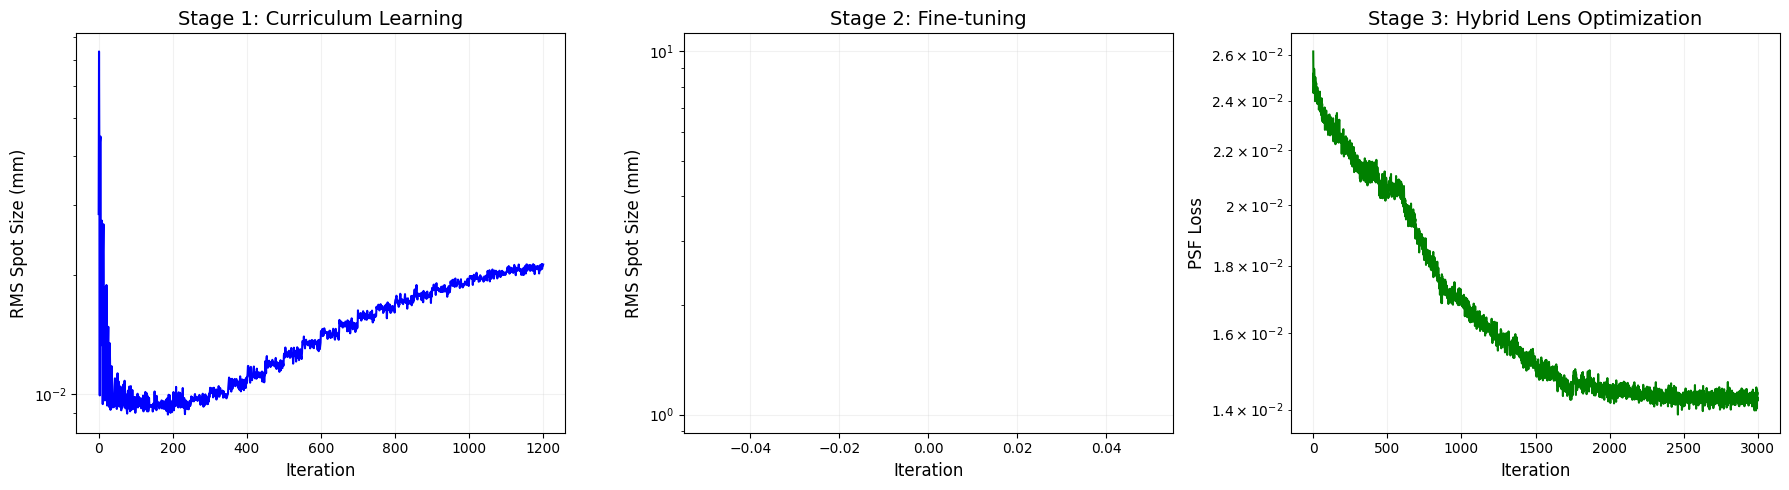

In [64]:
# Plot comprehensive loss curve comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='white')

# Stage 1: Curriculum learning
axes[0].plot(loss_history, linewidth=1.5, color='blue')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('RMS Spot Size (mm)', fontsize=12)
axes[0].set_title('Stage 1: Curriculum Learning', fontsize=14)
axes[0].set_yscale('log')
axes[0].grid(True, alpha=0.3, color='lightgray')
axes[0].set_facecolor('white')

# Stage 2: Fine-tuning
if 'loss_history_finetune' in locals() and loss_history_finetune is not None:
    axes[1].plot(loss_history_finetune, linewidth=1.5, color='orange')
else:
    axes[1].text(0.5, 0.5, "Data Missing\n(Restart kernel to fix)", ha='center', va='center')
    
axes[1].set_xlabel('Iteration', fontsize=12)
axes[1].set_ylabel('RMS Spot Size (mm)', fontsize=12)
axes[1].set_title('Stage 2: Fine-tuning', fontsize=14)
axes[1].set_yscale('log')
axes[1].grid(True, alpha=0.3, color='lightgray')
axes[1].set_facecolor('white')

# Hybrid lens optimization
axes[2].plot(hybrid_loss_history, linewidth=1.5, color='green')
axes[2].set_xlabel('Iteration', fontsize=12)
axes[2].set_ylabel('PSF Loss', fontsize=12)
axes[2].set_title('Stage 3: Hybrid Lens Optimization', fontsize=14)
axes[2].set_yscale('log')
axes[2].grid(True, alpha=0.3, color='lightgray')
axes[2].set_facecolor('white')

plt.tight_layout()
plt.savefig(f"{result_dir}/all_loss_curves.png", dpi=150, facecolor='white')
plt.show()

## 总结

本教程演示了使用 DeepLens 框架进行端到端光学设计的完整流程：

### 主要步骤回顾

1. **透镜创建**: 使用 `create_lens()` 创建5片非球面透镜，设置目标参数：
   - 焦距 8.0mm
   - FOV 80°
   - 总厚度 10mm
   - F/2.0

2. **端到端优化**: 使用课程学习策略和基于RMS的损失函数优化透镜设计
   - Stage 1: 课程学习优化
   - Stage 2: 精细化调优

3. **DOE混合透镜设计**: 使用 `HybridLens` 类添加DOE (Binary2) 层
   - 使用径向多项式相位模型
   - 射线-波动混合模型计算PSF

4. **端到端联合训练**: 混合透镜 + UNet神经网络
   - 可微分光学渲染
   - 图像重建网络协同优化

5. **超表面混合透镜**: 使用 `Pixel2D` 超表面
   - 每像素独立相位控制
   - 更高的设计自由度

6. **独立测试模块**: 支持直接加载已保存模型进行测试
   - 无需重新训练
   - 多透镜对比测试

### 关键API总结

| 功能 | API |
|------|-----|
| 创建透镜 | `GeoLens(filename=...)` 或 `create_lens(...)` |
| 设置目标参数 | `lens.set_target_fov_fnum(rfov, fnum)` |
| 获取优化器 | `lens.get_optimizer(lrs=[d,c,k,ai])` |
| 可微渲染 | `lens.render(img)` |
| 计算PSF | `lens.psf(points, ks, wvln)` |
| 综合分析 | `lens.analysis(save_name=...)` |
| 创建DOE混合透镜 | `HybridLens(filename=...)` with Binary2 |
| 创建超表面混合透镜 | `HybridLens(filename=...)` with Pixel2D |
| 混合透镜PSF | `hybrid_lens.psf(points, ks, wvln, spp)` |
| UNet后处理 | `UNet(in_channels=3, out_channels=3)` |

### 新增功能

- **参数配置**: 焦距8mm, FOV 80°, 厚度10mm
- **端到端训练**: 混合透镜 + UNet联合优化
- **超表面支持**: Pixel2D逐像素相位优化
- **独立测试**: 可直接加载保存的模型进行测试，避免从头运行

### 进一步学习

- 查看 `1_end2end_lens_design.py` 了解完整的端到端光学-网络联合设计
- 查看 `6_hybridlens_design.py` 了解更多混合透镜优化技巧
- 参考 DeepLens 文档获取更多API详情

In [16]:
# List all generated files
print("=" * 60)
print("Generated Files List")
print("=" * 60)

import glob
files = glob.glob(f"{result_dir}/*")
for f in sorted(files):
    print(f"  {os.path.basename(f)}")

print(f"\nAll results saved to: {result_dir}")

Generated Files List
  all_loss_curves.png
  doe_phase_map.png
  final_lens.json
  final_lens.png
  final_lens.zmx
  final_lens_mtf.png
  final_lens_render.png
  final_lens_spot.png
  fine-tune
  geolens_final_analysis_render.png
  hybrid_final.json
  hybrid_iter0.json
  hybrid_iter100.json
  hybrid_iter1000.json
  hybrid_iter1050.json
  hybrid_iter1100.json
  hybrid_iter1150.json
  hybrid_iter1200.json
  hybrid_iter1250.json
  hybrid_iter1300.json
  hybrid_iter1350.json
  hybrid_iter1400.json
  hybrid_iter1450.json
  hybrid_iter150.json
  hybrid_iter1500.json
  hybrid_iter1550.json
  hybrid_iter1600.json
  hybrid_iter1650.json
  hybrid_iter1700.json
  hybrid_iter1750.json
  hybrid_iter1800.json
  hybrid_iter1850.json
  hybrid_iter1900.json
  hybrid_iter1950.json
  hybrid_iter200.json
  hybrid_iter2000.json
  hybrid_iter250.json
  hybrid_iter300.json
  hybrid_iter350.json
  hybrid_iter400.json
  hybrid_iter450.json
  hybrid_iter50.json
  hybrid_iter500.json
  hybrid_iter550.json
  hybr